# JAX JIT Compilation

This notebook walks through the `spotgp` workflow using `TrapezoidSymmetricEnvelope`.

```{admonition} Sections

1. **Inspect** the envelope — parameter keys and analytic (sympy) equations  
2. **Build** a `SpotEvolutionModel` from envelope + visibility components  
3. **Simulate** a stellar lightcurve with `LightcurveModel`  
4. **Warm up JAX** with `build_jax()` before fitting  
```

```{seealso}

For GP hyperparameter fitting, see [`gp_optimization.ipynb`](https://spotgp.readthedocs.io/en/latest/tutorials/gp_optimization.html).
```

In [ ]:
import sys
sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt

from spotgp import (
    TrapezoidSymmetricEnvelope,
    VisibilityFunction,
    SpotEvolutionModel,
    LightcurveModel,
    AnalyticKernel,
)

np.random.seed(42)

---
## 1. Inspect the envelope

The symmetric trapezoid envelope has a linear rise over `tau_spot`, a flat plateau of duration `lspot`, then a symmetric linear decay.

In [2]:
envelope = TrapezoidSymmetricEnvelope(
    lspot=15.0,     # plateau duration [days]
    tau_spot=5.0,   # rise/decay timescale [days]
)

# param_dict maps parameter names to their current values
print("param_dict :", envelope.param_dict)
print("tau_spot   :", envelope.tau_spot)
print("lspot      :", envelope.lspot)
print("kernel_support:", envelope.kernel_support(), "days")

param_dict : {'lspot': 15.0, 'tau_spot': 5.0}
tau_spot   : 5.0
lspot      : 15.0
kernel_support: 25.0 days


### Analytic equations via `get_sympy()`

`get_sympy()` prints LaTeX for every function that has a closed-form analytic expression.  
Functions without one (e.g. `R_Gamma` for the trapezoid) are labeled `[numerical]`.

In [3]:
_ = envelope.get_sympy()

TrapezoidSymmetricEnvelope
  $\Gamma(t) = \begin{cases} 0 & \text{for}\: t < - \frac{\ell}{2} - \tau_{\rm spot} \\\frac{\frac{\ell}{2} + \tau_{\rm spot} + t}{\tau_{\rm spot}} & \text{for}\: t < - \frac{\ell}{2} \\1 & \text{for}\: t \leq \frac{\ell}{2} \\\frac{\frac{\ell}{2} + \tau_{\rm spot} - t}{\tau_{\rm spot}} & \text{for}\: t < \frac{\ell}{2} + \tau_{\rm spot} \\0 & \text{otherwise} \end{cases}$
  $\hat{\Gamma}(\omega) = \frac{4 \left(\omega \tau_{\rm spot} \cos{\left(\frac{\ell \omega}{2} \right)} + \sin{\left(\frac{\ell \omega}{2} \right)} - \sin{\left(\frac{\ell \omega}{2} + \omega \tau_{\rm spot} \right)}\right)}{\omega^{3} \tau_{\rm spot}^{2}}$
  $R_{\Gamma}(\tau) = \text{[numerical]}$


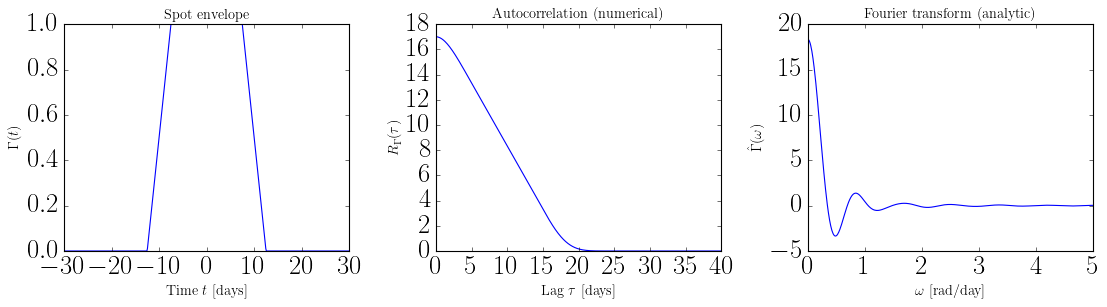

In [4]:
import jax.numpy as jnp

t = np.linspace(-30, 30, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(t, envelope.Gamma(jnp.array(t)))
axes[0].set_xlabel("Time $t$ [days]", fontsize=13)
axes[0].set_ylabel(r"$\Gamma(t)$", fontsize=13)
axes[0].set_title("Spot envelope", fontsize=13)

lag = np.linspace(0, 40, 500)
axes[1].plot(lag, envelope.R_Gamma(jnp.array(lag)))
axes[1].set_xlabel(r"Lag $\tau$ [days]", fontsize=13)
axes[1].set_ylabel(r"$R_\Gamma(\tau)$", fontsize=13)
axes[1].set_title("Autocorrelation (numerical)", fontsize=13)

omega = np.linspace(0, 5, 500)
axes[2].plot(omega, envelope.Gamma_hat(jnp.array(omega)))
axes[2].set_xlabel(r"$\omega$ [rad/day]", fontsize=13)
axes[2].set_ylabel(r"$\hat{\Gamma}(\omega)$", fontsize=13)
axes[2].set_title("Fourier transform (analytic)", fontsize=13)

fig.tight_layout()
plt.show()

---
## 2. Build a `SpotEvolutionModel`

A `SpotEvolutionModel` combines:
- an **`EnvelopeFunction`** — spot size evolution  
- a **`VisibilityFunction`** — stellar rotation geometry  
- an amplitude (`sigma_k`, or the physical triplet `nspot_rate + fspot + alpha_max`)

In [5]:
visibility = VisibilityFunction(
    peq=10.0,       # equatorial rotation period [days]
    kappa=0.3,      # differential rotation shear
    inc=np.pi / 3,  # stellar inclination [rad]
)

print("param_keys:", visibility.param_keys)
print("param_dict:", visibility.param_dict)

param_keys: ('peq', 'kappa', 'inc')
param_dict: {'peq': 10.0, 'kappa': 0.3, 'inc': 1.0471975511965976}


In [6]:
# The visibility function encodes differential rotation (omega_0)
# and the Fourier series coefficients c_n that describe how the flux
# from a spot at latitude phi varies over a full rotation.
_ = visibility.get_sympy()

VisibilityFunction
  $\omega_0(\phi) = \frac{2 \pi \left(- \kappa \sin^{2}{\left(\phi \right)} + 1\right)}{P_{\rm eq}}$
  $a_0 = \sin{\left(\phi \right)} \cos{\left(i \right)}$
  $a_1 = \sin{\left(i \right)} \cos{\left(\phi \right)}$
  $\theta_v = \operatorname{acos}{\left(- \frac{a_{0}}{a_{1}} \right)}$
  $c_0 = \frac{\theta_{v} a_{0} + a_{1} \sin{\left(\theta_{v} \right)}}{\pi}$
  $c_1 = \frac{a_{0} \sin{\left(\theta_{v} \right)} + \frac{a_{1} \left(\theta_{v} + \sin{\left(\theta_{v} \right)} \cos{\left(\theta_{v} \right)}\right)}{2}}{\pi}$
  $c_n = \frac{\frac{a_{0} \sin{\left(\theta_{v} n \right)}}{n} + \frac{a_{1} \left(\frac{\sin{\left(\theta_{v} \left(n + 1\right) \right)}}{n + 1} + \frac{\sin{\left(\theta_{v} \left(n - 1\right) \right)}}{n - 1}\right)}{2}}{\pi}$ $(n \geq 2)$


In [7]:
model = SpotEvolutionModel(
    envelope=envelope,
    visibility=visibility,
    sigma_k=0.01,   # kernel amplitude
)

# param_keys is envelope-aware: the order is always
# (peq, kappa, inc, <envelope params>, sigma_k)
print("param_keys:", model.param_keys)
print()
print(model)

param_keys: ('peq', 'kappa', 'inc', 'lspot', 'tau_spot', 'sigma_k')

SpotEvolutionModel(
  envelope=TrapezoidSymmetricEnvelope({'lspot': 15.0, 'tau_spot': 5.0}),
  visibility=VisibilityFunction(peq=10.0, kappa=0.3, inc=1.047),
  sigma_k=0.01
)


In [8]:
# SpotEvolutionModel.get_sympy() delegates to both sub-components
_ = model.get_sympy()

SpotEvolutionModel
  envelope  : TrapezoidSymmetricEnvelope
  visibility: VisibilityFunction

TrapezoidSymmetricEnvelope
  $\Gamma(t) = \begin{cases} 0 & \text{for}\: t < - \frac{\ell}{2} - \tau_{\rm spot} \\\frac{\frac{\ell}{2} + \tau_{\rm spot} + t}{\tau_{\rm spot}} & \text{for}\: t < - \frac{\ell}{2} \\1 & \text{for}\: t \leq \frac{\ell}{2} \\\frac{\frac{\ell}{2} + \tau_{\rm spot} - t}{\tau_{\rm spot}} & \text{for}\: t < \frac{\ell}{2} + \tau_{\rm spot} \\0 & \text{otherwise} \end{cases}$
  $\hat{\Gamma}(\omega) = \frac{4 \left(\omega \tau_{\rm spot} \cos{\left(\frac{\ell \omega}{2} \right)} + \sin{\left(\frac{\ell \omega}{2} \right)} - \sin{\left(\frac{\ell \omega}{2} + \omega \tau_{\rm spot} \right)}\right)}{\omega^{3} \tau_{\rm spot}^{2}}$
  $R_{\Gamma}(\tau) = \text{[numerical]}$

VisibilityFunction
  $\omega_0(\phi) = \frac{2 \pi \left(- \kappa \sin^{2}{\left(\phi \right)} + 1\right)}{P_{\rm eq}}$
  $a_0 = \sin{\left(\phi \right)} \cos{\left(i \right)}$
  $a_1 = \sin{\left(i \r

---
## 3. Simulate a stellar lightcurve

`LightcurveModel.from_spot_model()` builds a forward simulation directly from the `SpotEvolutionModel`, so there is no need to repeat parameters.

In [9]:
lc = LightcurveModel.from_spot_model(
    spot_model=model,
    nspot=30,       # total number of spots to place
    tsim=150,       # simulation duration [days]
    tsamp=0.5,      # cadence [days]
    lat=[-np.pi / 2, np.pi / 2],
    long=[0, 2 * np.pi],
)

print(f"Lightcurve: {len(lc.t)} points  "
      f"[{lc.t[0]:.1f} – {lc.t[-1]:.1f} days]")
print(f"Flux:  mean={np.mean(lc.flux):.5f}  std={np.std(lc.flux):.5f}")

Lightcurve: 300 points  [0.0 – 149.5 days]
Flux:  mean=0.99227  std=0.00727


In [10]:
# Add realistic photometric noise
sigma_n = 0.3 * np.std(lc.flux)  # noise ~ 30 % of signal std
flux_obs = lc.flux + np.random.normal(0, sigma_n, lc.flux.shape)
flux_err = np.full_like(flux_obs, sigma_n)

tobs = lc.t

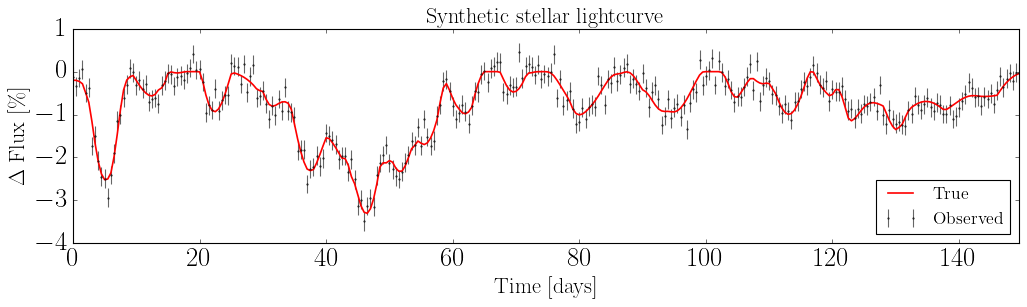

In [16]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.errorbar(tobs, (flux_obs - 1) * 100, yerr=flux_err * 100,
            fmt=".k", ms=3, capsize=0, alpha=0.6, label="Observed")
ax.plot(lc.t, (lc.flux - 1) * 100, "r-", lw=1.5, label="True")
ax.set_xlabel("Time [days]", fontsize=20)
ax.set_ylabel(r"$\Delta$ Flux [\%]", fontsize=20)
ax.set_title("Synthetic stellar lightcurve", fontsize=20)
ax.legend(fontsize=16, loc="lower right")
ax.set_xlim(tobs[0], tobs[-1])
fig.tight_layout()
plt.show()

---
## 4. Warm up JAX with `build_jax()`

JAX compiles computation graphs to XLA on the **first** call for each new input shape. That compilation can take 5–30 s and is easy to mistake for slow runtime. 

Call `build_jax()` **once after construction** to pay the compile cost upfront:

| Class | What gets compiled |
|---|---|
| `AnalyticKernel` | `kernel()` (`jax.lax.scan`) and `compute_psd()` (`jax.vmap`) |
| `GPSolver` | `log_posterior`, `neg_log_posterior`, `grad_log_posterior`, `grad_neg_log_posterior` |

After `build_jax()`, every subsequent call at the same input shape will be fast.

In [17]:
# Build the analytic kernel and warm up its JAX computation
ak = AnalyticKernel(model).build_jax()

# Subsequent kernel evaluations are fast
import time
lag = np.linspace(0, 3 * model.peq, 300)
t0 = time.time()
K = ak.kernel(lag)
print(f"Kernel eval (post-compile): {(time.time() - t0)*1e3:.1f} ms")

JAX kernel compiled in 3.66s
Kernel eval (post-compile): 625.7 ms


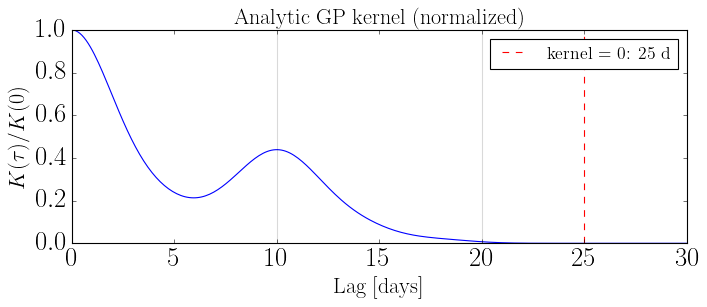

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lag, K / K[0])
for n in range(int(lag[-1] / model.peq) + 1):
    ax.axvline(n * model.peq, color="k", alpha=0.15, lw=1)
ax.axvline(envelope.kernel_support(), color="r", ls="--",
           label=f"kernel = 0: {envelope.kernel_support():.0f} d")
ax.set_xlabel("Lag [days]", fontsize=20)
ax.set_ylabel(r"$K(\tau) / K(0)$", fontsize=20)
ax.set_title("Analytic GP kernel (normalized)", fontsize=20)
ax.legend(fontsize=16)
fig.tight_layout()
plt.show()